In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
from scipy.optimize import curve_fit
plt.rcParams['font.sans-serif'] = ['Source Han Sans CN']  # 设置黑体（Windows常用）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题


In [13]:
y = np.array([ 0.02687641  , -0.051838174 , -0.038682293 , -0.011162247 ,
        0.0514594   ,  0.0015487452,  0.008841529 , -0.021822562 ,
       -0.0037563026,  0.0023013342,  0.0237432   , -0.061686277 ,
        0.0012111354,  0.02906402  , -0.032050617 ,  0.037810057 ,
        0.008440045 ,  0.035917632 ,  0.020213906 , -0.0059090927,
       -0.046507243 , -0.052811813 , -0.061633557 ,  0.043665994 ,
       -0.05135289  , -0.0065911664, -0.026587121 ,  0.04992829  ,
        0.014614849 , -0.014922703 , -0.03908735  , -0.0486842   ,
        0.015602052 ,  0.01154507  , -0.017084816 , -0.029270075 ,
        0.017744616 , -0.086902365 , -0.057092957 ,  0.014562607 ,
       -0.05927294  , -0.024685241 ,  0.0014375789, -0.025105542 ,
       -0.025280412 ,  0.016757516 , -0.047529384 , -0.033562593 ,
        0.008304576 ,  0.026807703 , -0.027133863 , -0.039325528 ,
       -0.034574233 , -0.06792921  ,  0.0080153   ,  0.028783064 ,
       -0.02821912  ,  0.0067527834, -0.024251558 , -0.0077012205,
        0.027128652 ,  0.02327926  , -0.03461707  , -0.03479245  ,
       -0.064421356 , -0.0038739173, -0.036828045 , -0.0010905216,
       -0.061686244 ,  0.018016646 , -0.047358714 , -0.0255251   ,
       -0.037854083 , -0.002461705 ,  0.025087485 , -0.0734397   ,
       -0.022554424 , -0.033740375 ,  0.006361188 , -0.026950091 ,
       -0.018310858 , -0.005080465 , -0.016037753 , -0.024010878 ,
       -0.049128912 , -0.025761453 , -0.063119225 , -0.042262647 ,
       -0.028787326 , -0.052737758 , -0.04496848  , -0.02033897  ,
       -0.043826647 , -0.021735143 , -0.049609873 , -0.09624004  ,
       -0.023232276 , -0.008906729 , -0.068380035 , -0.0011446229,
       -0.03236728  , -0.11484849  , -0.014321152 , -0.023647679 ,
       -0.044718646 , -0.044204377 , -0.035060223 , -0.054341886 ,
       -0.07815235  , -0.058056086 , -0.025192548 , -0.06600602  ,
       -0.006601578 , -0.06453136  , -0.0071393135,  0.0067788935,
       -0.0010270653, -0.023615774 , -0.06471622  , -0.077475175 ,
       -0.050834842 , -0.08406323  , -0.031887565 , -0.045211405 ,
       -0.021213865 , -0.04203769  , -0.04591224  , -0.045067072 ,
       -0.06049677  , -0.0645177   , -0.0042455955, -0.040894948 ,
       -0.060304992 , -0.08064115  , -0.055870242 , -0.062545195 ,
       -0.022273999 , -0.015831577 , -0.03183268  , -0.043361217 ,
        0.003842021 , -0.028778393 , -0.040605772 , -0.020500166 ,
       -0.0026501976, -0.014835012 , -0.06558895  , -0.06251776  ,
       -0.028933953 , -0.018771397 , -0.022434006 , -0.029827341 ,
       -0.013391526 , -0.036868718 ,  0.03629145  ,  0.0009706221,
       -0.026122155 ,  0.011839725 ,  0.057541262 , -0.03252746  ,
       -0.024447411 ,  0.0040628496,  0.013544074 ,  0.038330384 ,
        0.0016807639,  0.039976075 ,  0.011305841 ,  0.019486051 ,
       -0.01018109  , -0.037567616 ,  0.014592757 ,  0.04385451  ,
        0.017687192 ,  0.015072993 ,  0.040112384 ,  0.013052284 ,
        0.08827833  ,  0.059025034 ,  0.05043488  ,  0.074758455 ,
        0.058640603 ,  0.0505887   ,  0.049921863 ,  0.06359861  ,
        0.09973443  ,  0.047054514 ,  0.05279908  ,  0.06710027  ,
        0.07866887  ,  0.060253266 ,  0.09948667  ,  0.09868702  ,
        0.09309897  ,  0.13353795  ,  0.115225755 ,  0.12709388  ,
        0.14060725  ,  0.13735105  ,  0.11863454  ,  0.15078622  ,
        0.1138698   ,  0.1703982   ,  0.14808527  ,  0.18220133  ,
        0.19447815  ,  0.1909352   ,  0.21515624  ,  0.1525391   ,
        0.23423705  ,  0.20023708  ,  0.18542697  ,  0.169304    ,
        0.18593845  ,  0.20238872  ,  0.18771248  ,  0.25713992  ,
        0.19566064  ,  0.21559404  ,  0.22579388  ,  0.24526581  ,
        0.23307139  ,  0.2290453   ,  0.21442287  ,  0.21689674  ,
        0.22546251  ,  0.19079208  ,  0.19520868  ,  0.22431193  ,
        0.23981038  ,  0.22326255  ,  0.23446064  ,  0.26161996  ,
        0.26082152  ,  0.30179903  ,  0.26711112  ,  0.28320742  ,
        0.25744846  ,  0.24976406  ,  0.2642514   ,  0.2422521   ,
        0.1929575   ,  0.27870622  ,  0.26023003  ,  0.22905551  ,
        0.22221959  ,  0.25296786  ,  0.2647657   ,  0.26743302  ,
        0.24234577  ,  0.25801206  ,  0.27046826  ,  0.2643061   ,
        0.23080799  ,  0.2310953   ,  0.2106463   ,  0.19638984  ,
        0.22507636  ,  0.23871143  ,  0.24759959  ,  0.2543972   ,
        0.21306676  ,  0.22900048  ,  0.20514975  ,  0.22653727  ,
        0.19382101  ,  0.19288555  ,  0.21496983  ,  0.22732677  ,
        0.25903535  ,  0.19830233  ,  0.19788241  ,  0.21447049  ,
        0.21940103  ,  0.19620557  ,  0.12092713  ,  0.18519546  ,
        0.13731065  ,  0.18762226  ,  0.14666715  ,  0.1816778   ,
        0.12778318  ,  0.1400923   ,  0.1518645   ,  0.1349883   ,
        0.15749249  ,  0.15150294  ,  0.1362592   ,  0.15760191  ,
        0.13205968  ,  0.09687962  ,  0.11161271  ,  0.18873939  ,
        0.17699541  ,  0.111357614 ,  0.13905695  ,  0.2051738   ,
        0.11129183  ,  0.10942376  ,  0.063834645 ,  0.088339135 ,
        0.09903345  ,  0.08952198  ,  0.11348698  ,  0.09093173  ,
        0.055851225 ,  0.08371051  ,  0.079779886 ,  0.015971424 ,
        0.10599496  ,  0.030591916 ,  0.01746191  ,  0.06948549  ,
        0.07689959  ,  0.048427455 ,  0.09276287  ,  0.02544825  ,
       -0.012409107 ,  0.033375055 , -0.0000931025,  0.021918057 ,
        0.052115917 ,  0.013470884 ,  0.0064934213,  0.0054051545,
       -0.014300569 ,  0.014391469 , -0.005004126 ,  0.004879117 ,
       -0.023495918 , -0.0006824787,  0.029075053 , -0.015879912 ,
       -0.02675313  ,  0.0285254   , -0.05456907  , -0.084218726 ,
       -0.03535717  , -0.029956447 , -0.055767853 , -0.016695935 ,
        0.008568771 , -0.06985674  , -0.042070426 , -0.0275295   ,
       -0.05747124  , -0.054655954 , -0.027089275 , -0.048303433 ,
       -0.08338936  , -0.05877906  , -0.056667596 , -0.03625038  ,
       -0.0366167   , -0.04874647  , -0.10054341  , -0.063845545 ,
       -0.07076698  , -0.08906256  , -0.07605582  , -0.06835832  ,
       -0.09355978  , -0.098922454 , -0.08800813  , -0.0978907   ,
       -0.10280027  , -0.07786088  , -0.09230445  , -0.071361646 ,
       -0.0993083   , -0.050537985 , -0.086287715 , -0.068034574 ,
       -0.11825753  , -0.12654261  , -0.08576214  , -0.0739993   ,
       -0.096702695 , -0.069499485 , -0.0644165   , -0.11597077  ,
       -0.09501101  , -0.094479114 , -0.1127216   , -0.09985515  ,
       -0.09169121  , -0.08218975  , -0.11176738  , -0.043219555 ,
       -0.06205584  , -0.07723577  , -0.10751627  , -0.080833964 ,
       -0.056703392 , -0.076642826 , -0.043674503 , -0.116917826 ,
       -0.07824867  , -0.11609453  , -0.108419985 , -0.04343034  ,
       -0.09385399  , -0.07326463  , -0.093115166 , -0.03173955  ,
       -0.05485738  , -0.12562992  , -0.072859675 , -0.040250998 ,
       -0.04968109  , -0.0903158   , -0.042861175 , -0.047028888 ,
       -0.043520596 , -0.10065211  , -0.035969492 , -0.100215696 ,
       -0.064105935 , -0.048654117 , -0.043276913 , -0.057608634 ,
       -0.019602664 , -0.02142693  , -0.06195086  , -0.05182529  ,
       -0.028177908 , -0.022047712 , -0.030558031 , -0.033080973 ,
        0.0013709276, -0.031038124 ,  0.0038372146,  0.021523977 ,
       -0.04099476  ,  0.01697891  ,  0.037766706 , -0.032823175 ,
       -0.051564664 , -0.022763666 ,  0.02976128  ,  0.007291216 ,
        0.049775884 ,  0.057386972 ,  0.032643735 ,  0.02142795  ,
        0.08487736  ,  0.011419928 ,  0.04138618  ,  0.07809896  ,
        0.015681928 ,  0.063998185 ,  0.075699724 ,  0.08670011  ,
        0.09836244  ,  0.124596305 ,  0.11092163  ,  0.11202278  ,
        0.100170545 ,  0.11088377  ,  0.15098579  ,  0.18209     ,
        0.13642268  ,  0.1467987   ,  0.2007328   ,  0.19046083  ,
        0.16958699  ,  0.19717287  ,  0.17150518  ,  0.2500751   ,
        0.27344373  ,  0.23648188  ,  0.23464379  ,  0.2692482   ,
        0.3269023   ,  0.24315931  ,  0.25448734  ,  0.32100675  ,
        0.3159743   ,  0.3318963   ,  0.3249182   ,  0.33226034  ,
        0.35801286  ,  0.32428312  ,  0.40605178  ,  0.43498048  ,
        0.40166163  ,  0.45362553  ,  0.48894632  ,  0.41964558  ,
        0.46496484  ,  0.42543224  ,  0.5030597   ,  0.4654101   ,
        0.500765    ,  0.5445628   ,  0.562857    ,  0.5653483   ,
        0.5842777   ,  0.5689759   ])
x = np.linspace(200.0038336395, 99.9658870572, 498)

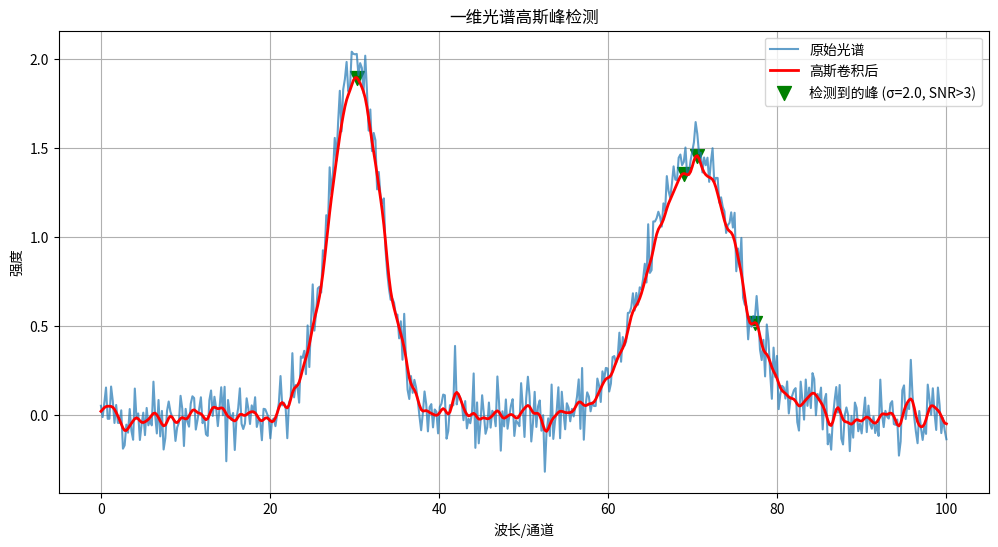

检测到的峰位置索引: [151 344 352 386]
对应波长/通道位置: [30.26052104 68.93787575 70.54108216 77.35470942]


In [9]:
def gaussian_kernel(sigma, kernel_size):
    """生成高斯核"""
    x = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)
    kernel = np.exp(-x**2/(2*sigma**2)) / (sigma*np.sqrt(2*np.pi))
    return kernel

def detect_gaussian_peak(spectrum, sigma=3.0, kernel_size=21, threshold=3.0):
    """
    检测光谱中的高斯形状突起
    参数:
        spectrum: 输入一维光谱
        sigma: 高斯核的标准差
        kernel_size: 卷积核大小
        threshold: 信噪比阈值
    返回:
        peaks: 检测到的峰位置索引
        convolved: 卷积后的光谱
    """
    # 生成高斯核
    kernel = gaussian_kernel(sigma, kernel_size)

    # 卷积运算（使用same模式保持长度不变）
    convolved = convolve(spectrum, kernel, mode='same')

    # 计算噪声水平（使用光谱两端无信号区域）
    noise_region = np.concatenate([spectrum[:50], spectrum[-50:]])
    noise_mean = np.mean(noise_region)
    noise_std = np.std(noise_region)

    # 寻找显著峰（超过threshold*sigma的峰）
    peaks = []
    for i in range(1, len(convolved)-1):
        # 简单的局部极大值检测
        if (convolved[i] > convolved[i-1]) and (convolved[i] > convolved[i+1]):
            snr = (convolved[i] - noise_mean) / noise_std
            if snr > threshold:
                peaks.append(i)

    return np.array(peaks), convolved

# 示例使用 --------------------------------------------------

# 生成模拟光谱（含高斯峰）
np.random.seed(42)

# 添加两个高斯峰
x = np.linspace(0, 100, 500)
spectrum = np.random.normal(0, 0.1, len(x))  # 基线噪声
spectrum += 2.0 * np.exp(-(x-30)**2/(2*3**2))  # 第一个峰
spectrum += 1.5 * np.exp(-(x-70)**2/(2*5**2))  # 第二个峰

# 检测高斯峰
peaks, convolved = detect_gaussian_peak(spectrum, sigma=2.0, threshold=3.0)
# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x, spectrum, label='原始光谱', alpha=0.7)
plt.plot(x, convolved, label='高斯卷积后', color='red', linewidth=2)
plt.scatter(x[peaks], convolved[peaks], color='green', s=100,
            label=f'检测到的峰 (σ={2.0}, SNR>3)', marker='v')
plt.legend()
plt.xlabel('波长/通道')
plt.ylabel('强度')
plt.title('一维光谱高斯峰检测')
plt.grid(True)
plt.show()
print(f"检测到的峰位置索引: {peaks}")
print(f"对应波长/通道位置: {x[peaks]}")

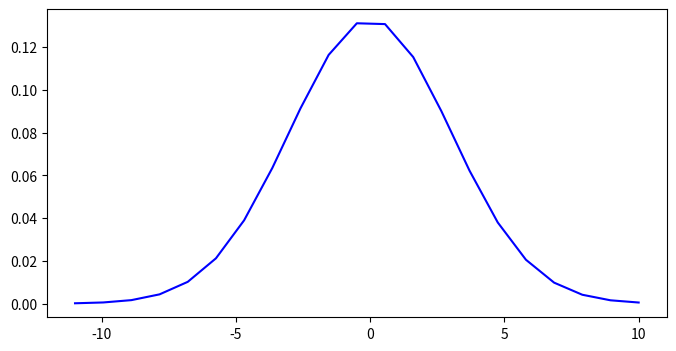

In [15]:
def gaussian_kernel(sigma, kernel_size):
    """生成高斯核"""
    x = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)
    kernel = np.exp(-x**2/(2*sigma**2)) / (sigma*np.sqrt(2*np.pi))
    return kernel

sigma=3.0
kernel_size=21
x_ = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)
kernel = np.exp(-x_**2/(2*sigma**2)) / (sigma*np.sqrt(2*np.pi))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_, kernel, label=f'高斯核 (σ={sigma})', color='blue')
plt.show()

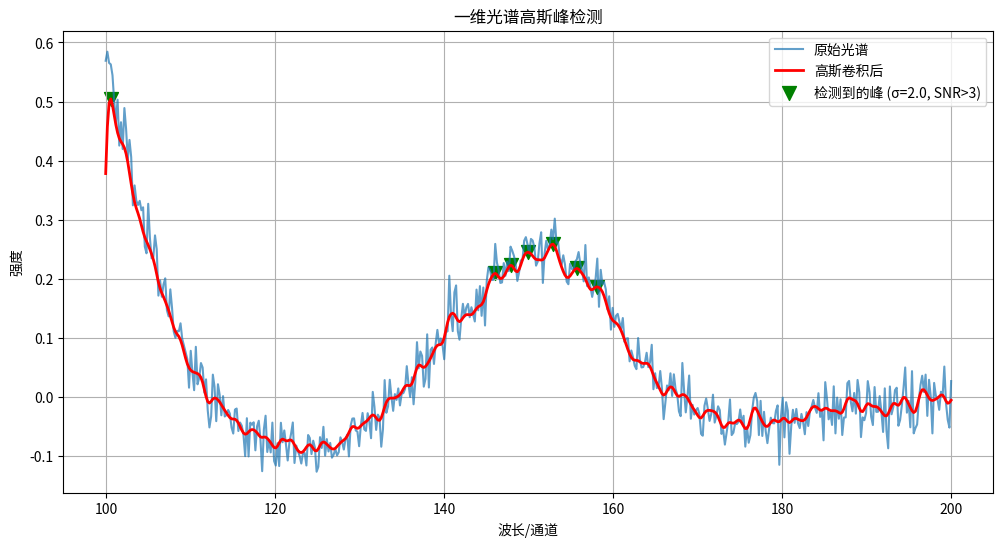

检测到的峰位置索引: [208 220 234 249 259 268 494]
对应波长/通道位置: [158.13684594 155.7214428  152.90347247 149.88421855 147.8713826
 146.05983025 100.56973784]


In [16]:
peaks, convolved = detect_gaussian_peak(y, sigma=2.0, threshold=0.1)
# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='原始光谱', alpha=0.7)
plt.plot(x, convolved, label='高斯卷积后', color='red', linewidth=2)
plt.scatter(x[peaks], convolved[peaks], color='green', s=100,
            label=f'检测到的峰 (σ={2.0}, SNR>3)', marker='v')
plt.legend()
plt.xlabel('波长/通道')
plt.ylabel('强度')
plt.title('一维光谱高斯峰检测')
plt.grid(True)
plt.show()
print(f"检测到的峰位置索引: {peaks}")
print(f"对应波长/通道位置: {x[peaks]}")

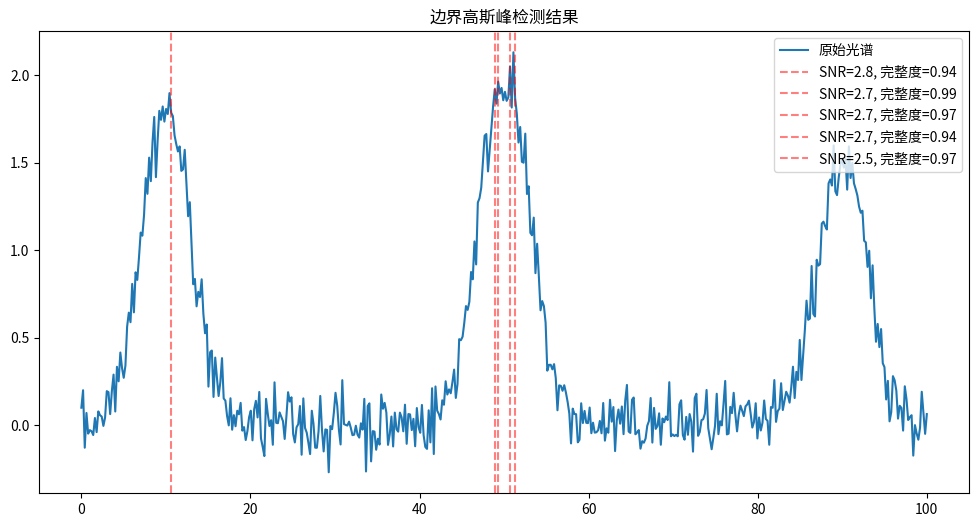

In [4]:
import numpy as np
from scipy.signal import convolve
from scipy.optimize import curve_fit

def asymmetric_gaussian_kernel(sigma, kernel_size, position='full'):
    """
    生成非对称高斯核（处理边界峰）
    position: 'left'|'right'|'full'
    """
    x = np.linspace(-kernel_size//2, kernel_size//2, kernel_size)
    if position == 'left':
        kernel = np.exp(-x**2/(2*sigma**2)) * (x <= 0)
    elif position == 'right':
        kernel = np.exp(-x**2/(2*sigma**2)) * (x >= 0)
    else:
        kernel = np.exp(-x**2/(2*sigma**2))
    return kernel / kernel.sum()

def detect_partial_peaks(spectrum, sigma=3.0, kernel_size=21, threshold=3.0):
    # 镜像填充（避免边界效应）
    pad_size = kernel_size // 2
    padded_spec = np.pad(spectrum, pad_size, mode='reflect')

    # 生成三种核（完整/左半/右半高斯）
    kernel_full = asymmetric_gaussian_kernel(sigma, kernel_size, 'full')
    kernel_left = asymmetric_gaussian_kernel(sigma, kernel_size, 'left')
    kernel_right = asymmetric_gaussian_kernel(sigma, kernel_size, 'right')

    # 并行卷积
    conv_full = convolve(padded_spec, kernel_full, mode='valid')
    conv_left = convolve(padded_spec, kernel_left, mode='valid')
    conv_right = convolve(padded_spec, kernel_right, mode='valid')

    # 合并卷积结果（取各位置最优响应）
    conv_combined = np.maximum.reduce([conv_full, conv_left, conv_right])

    # 噪声估计（使用中间80%区域避免边界影响）
    valid_region = spectrum[int(len(spectrum)*0.1):int(len(spectrum)*0.9)]
    noise_mean = np.mean(valid_region)
    noise_std = np.std(valid_region)

    # 峰检测
    peaks = []
    for i in range(1, len(conv_combined)-1):
        if (conv_combined[i] > conv_combined[i-1]) and (conv_combined[i] > conv_combined[i+1]):
            snr = (conv_combined[i] - noise_mean) / noise_std
            if snr > threshold:
                # 判断峰完整性
                ratio_full = conv_full[i] / conv_combined[i]
                ratio_left = conv_left[i] / conv_full[i]
                ratio_right = conv_right[i] / conv_full[i]

                completeness = min(ratio_full, 1.0)  # 完整度估计
                peaks.append((i, completeness, snr))

    # 按信噪比排序返回
    return sorted(peaks, key=lambda x: -x[2])

# 测试用例
if __name__ == "__main__":
    x = np.linspace(0, 100, 500)
    spectrum = np.random.normal(0, 0.1, len(x))

    # 添加完整峰和两个边界峰
    spectrum += 2.0 * np.exp(-(x-50)**2/(2*3**2))  # 中心完整峰
    spectrum += 1.8 * np.exp(-(x-10)**2/(2*3**2))  # 左边界峰（不完整）
    spectrum += 1.5 * np.exp(-(x-90)**2/(2*3**2))  # 右边界峰（不完整）

    # 检测峰
    detected_peaks = detect_partial_peaks(spectrum, sigma=3.0, threshold=2.5)

    # 可视化
    plt.figure(figsize=(12, 6))
    plt.plot(x, spectrum, label='原始光谱')

    for peak_idx, completeness, snr in detected_peaks:
        plt.axvline(x[peak_idx], color='r', linestyle='--',
                   alpha=0.5, label=f'SNR={snr:.1f}, 完整度={completeness:.2f}')

    plt.legend()
    plt.title("边界高斯峰检测结果")
    plt.show()